In [2]:
from typing_extensions import TypedDict
class State(TypedDict):
    graph_info: str

In [3]:
def start_play(State):
    print(State)
    print("Start_play node has been called")
    return ({"graph_info":State["graph_info"] + " I am planning to play"})

def cricket(State):
    print(State)
    print("Cricket node has been called")
    return {"graph_info":State["graph_info"] + " I am playing cricket"}

def badminton(State):
    print(State)
    print("Badminton node has been called")
    return {"graph_info":State["graph_info"] + " I am playing badminton"}




In [4]:
import random
from typing import Literal

def random_play(State)->Literal["cricket","badminton"]:
    graph_info = State["graph_info"]

    if random.random()>0.5:
        return "cricket"
    else:
        return "badminton"

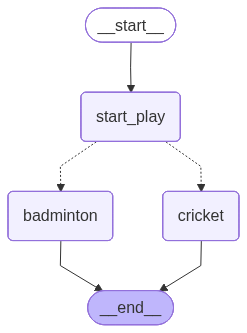

In [5]:
from IPython.display import Image,display
from langgraph.graph import StateGraph, START,END

graph = StateGraph(State)

graph.add_node("start_play",start_play)
graph.add_node("cricket",cricket)
graph.add_node("badminton", badminton)


graph.add_edge(START,"start_play")
graph.add_conditional_edges("start_play",random_play)
graph.add_edge("cricket",END)
graph.add_edge("badminton",END)


graph_builder = graph.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [6]:
graph_builder.invoke({"graph_info":'My name is Vishal'})
#

{'graph_info': 'My name is Vishal'}
Start_play node has been called
{'graph_info': 'My name is Vishal I am planning to play'}
Cricket node has been called


{'graph_info': 'My name is Vishal I am planning to play I am playing cricket'}

In [7]:
graph_builder.invoke({"graph_info":'My name is Vishal'})


{'graph_info': 'My name is Vishal'}
Start_play node has been called
{'graph_info': 'My name is Vishal I am planning to play'}
Cricket node has been called


{'graph_info': 'My name is Vishal I am planning to play I am playing cricket'}

### Streaming

In [11]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END

from typing import Annotated
from langgraph.graph.message import add_messages


In [12]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

In [16]:
import os
from dotenv import load_dotenv
from google.colab import userdata
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
#os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [21]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model = "groq:llama-3.1-8b-instant")

llm.invoke("HI")

AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.008909269, 'completion_tokens_details': None, 'prompt_time': 0.003968117, 'prompt_tokens_details': None, 'queue_time': 0.065847172, 'total_time': 0.012877386}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d6bf3-2065-78a0-b9ac-fbecc63d9129-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})

In [28]:
from langgraph.graph import message
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
def chatbot(State):
    return {"messages":[llm.invoke(State["messages"])]}


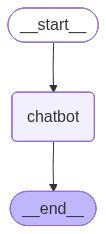

In [29]:
graph = StateGraph(State)

graph.add_node("chatbot",chatbot)

graph.add_edge(START,"chatbot")
graph.add_edge("chatbot",END)

graph_builder = graph.compile(checkpointer=memory)

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [30]:
config = {"configurable":{"thread_id":"1"}}

graph_builder.invoke({"messages": "Tell me the history of india"},
                     config=config)

{'messages': [HumanMessage(content='Tell me the history of india', additional_kwargs={}, response_metadata={}, id='a37d9ddd-a1a9-461c-89a1-21ed58daa157'),
  AIMessage(content='The history of India is a long and complex one, spanning thousands of years. It is a story of various empires, dynasties, invasions, and cultural exchanges that have shaped the country into what it is today.\n\n**Pre-History and Ancient India (3000 BCE - 500 CE)**\n\nThe Indus Valley Civilization, one of the earliest known civilizations in the world, flourished in the northwestern region of India between 3000 and 1500 BCE. The civilization is known for its sophisticated urban planning, architecture, and water management systems.\n\nAround 1500 BCE, the Vedic period began, marked by the composition of the Vedas, the sacred texts of Hinduism. This period saw the rise of the Vedic tribes, who were eventually unified under the rule of the Mauryan Empire.\n\nThe Mauryan Empire, founded by Chandragupta Maurya in 322 BC

### Streaming stream() and astream()

In [31]:
config = {"configurable":{"thread_id":"2"}}

for chunk in graph_builder.stream({"messages": "Tell me the history of india"},
                     config=config,stream_mode="updates"):
    print(chunk)


{'chatbot': {'messages': [AIMessage(content='What a vast and complex topic. The history of India spans over 5,000 years, with a rich and diverse cultural heritage. I\'ll try to provide a concise overview, highlighting the major periods and events that have shaped the country.\n\n**Ancient India (3300 BCE - 500 CE)**\n\n1. **Indus Valley Civilization (3300 BCE - 1300 BCE)**: This was one of the world\'s earliest urban civilizations, known for its sophisticated architecture, art, and water management systems.\n2. **Vedic Period (1500 BCE - 500 BCE)**: The Vedas, ancient Hindu scriptures, were composed during this period. The Vedic people developed a complex system of social hierarchy, with the Brahmins (priests) at the top.\n3. **Mauryan Empire (322 BCE - 185 BCE)**: Chandragupta Maurya founded the Mauryan Empire, which stretched from modern-day Afghanistan to Bangladesh. His grandson, Ashoka, converted to Buddhism and spread the teachings throughout the empire.\n4. **Gupta Empire (320 C

In [32]:
config = {"configurable":{"thread_id":"2"}}

for chunk in graph_builder.stream({"messages": "Tell me the history of india"},
                     config=config,stream_mode="values"):
    print(chunk)


{'messages': [HumanMessage(content='Tell me the history of india', additional_kwargs={}, response_metadata={}, id='6ee8b976-2012-4400-af6c-681275348560'), AIMessage(content='What a vast and complex topic. The history of India spans over 5,000 years, with a rich and diverse cultural heritage. I\'ll try to provide a concise overview, highlighting the major periods and events that have shaped the country.\n\n**Ancient India (3300 BCE - 500 CE)**\n\n1. **Indus Valley Civilization (3300 BCE - 1300 BCE)**: This was one of the world\'s earliest urban civilizations, known for its sophisticated architecture, art, and water management systems.\n2. **Vedic Period (1500 BCE - 500 BCE)**: The Vedas, ancient Hindu scriptures, were composed during this period. The Vedic people developed a complex system of social hierarchy, with the Brahmins (priests) at the top.\n3. **Mauryan Empire (322 BCE - 185 BCE)**: Chandragupta Maurya founded the Mauryan Empire, which stretched from modern-day Afghanistan to 

In [34]:
config = {"configurable":{"thread_id":"3"}}

async for chunk in graph_builder.astream_events({"messages": "Tell me the history of india"},
                     config=config,version="v2"):
    print(chunk)


{'event': 'on_chain_start', 'data': {'input': {'messages': 'Tell me the history of india'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019d6c07-d409-7dc1-b03e-0678e7a5908d', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Tell me the history of india', additional_kwargs={}, response_metadata={}, id='01401273-0c4e-4b40-b210-93cc6426e07e')]}}, 'name': 'chatbot', 'tags': ['graph:step:1'], 'run_id': '019d6c07-d40d-7651-8927-193f44d1b22f', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'chatbot', 'langgraph_triggers': ('branch:to:chatbot',), 'langgraph_path': ('__pregel_pull', 'chatbot'), 'langgraph_checkpoint_ns': 'chatbot:a64b6a26-8681-8cc8-e67a-bce11b09d560'}, 'parent_ids': ['019d6c07-d409-7dc1-b03e-0678e7a5908d']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Tell me the histor